# Observable-conditioned BIND — load a checkpoint & inspect

This notebook loads an **observable-conditioned** BIND checkpoint (`feature/observable-conditioning`,
e.g. the `fm_observables` run) and inspects how it's running. Unlike the standard model, this one is
conditioned on **aperture-integrated observables within R200** (`Y_200, Mgas_200, Mstar_200, Tx_200,
K_200, P_200, M_200`) measured from each halo's own maps — *not* the 35 params. The DMO map is still
the image conditioning, and the outputs are unchanged (`[DM_hydro, Gas, Stars]` + 4 thermo fields).

What we do here:
1. **Reconstruction** — condition each held-out halo on its *own* (truth-measured) observables and
   compare generated vs truth maps + per-channel dex error + stacked radial profiles.
2. **Conditioning response** — fix the DMO + all-but-one observable for a single halo, sweep one
   observable over ±dex, and watch the painted field respond (proof the observables are being used).
3. **Subset conditioning** *(needs a `--mask_observables` model)* — condition on only a survey-like
   subset (e.g. `Y, Tx, M`) and predict the **withheld** observables, including `Mgas, Mstar → f_b`.

The notebook auto-detects `mask_observables` and packs the conditioning accordingly, so it runs on
both the unmasked `fm_observables` and a masked `fm_observables_masked` checkpoint (section 4 activates
only for the latter). Point it at another run/checkpoint via `OBS_RUN_DIR` / `OBS_CKPT`. Kernel: `torch3`.

In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from bind.data import (load_file_list, AstroDataset, NormStats, THERMO_KEYS, N_THERMO,
                       OBSERVABLE_KEYS, N_OBS, compute_observables, r200_from_sample)
from bind.train import FlowMatchingLit
from bind.inference.pipeline import _denormalize_to_physical
from bind.metrics import radial_profile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

CHANNELS = ['DM_hydro', 'Gas', 'Stars'] + list(THERMO_KEYS)   # 3 mass + 4 thermo outputs
print('device:', device)
print('conditioning observables (N_OBS=%d):' % N_OBS, OBSERVABLE_KEYS)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


device: cuda
conditioning observables (N_OBS=7): ('Y_200', 'Mgas_200', 'Mstar_200', 'Tx_200', 'K_200', 'P_200', 'M_200')


## 1. Load the run (checkpoint + norm stats)

In [2]:
RUN_DIR   = Path(os.environ.get('OBS_RUN_DIR', '/mnt/home/mlee1/ceph/fm_runs/fm_observables_masked'))
CKPT      = os.environ.get('OBS_CKPT', 'last.ckpt')     # e.g. 'epoch007-val_loss0.1904.ckpt'
DATA_ROOT = Path(os.environ.get('BIND_DATA_ROOT', '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu'))
N_STEPS   = 50
N_HALOS   = 64                                           # held-out halos to evaluate

def _epoch(p):
    m = re.search(r'epoch(\d+)', Path(p).name)
    return int(m.group(1)) if m else '?'

ns = NormStats.load(RUN_DIR / 'norm_stats.npz')
assert ns.condition_observables, 'this run is NOT observable-conditioned (no obs stats in norm_stats)'
print(f'norm_stats: condition_observables={ns.condition_observables} '
      f'predict_thermo={ns.predict_thermo} stars_two_head={ns.stars_two_head} '
      f'mask_observables={ns.mask_observables}')
print('obs_mean :', np.round(ns.obs_mean, 3))
print('obs_std  :', np.round(ns.obs_std, 3))

ckpt_path = RUN_DIR / 'checkpoints' / CKPT
model = FlowMatchingLit.load_from_checkpoint(str(ckpt_path), map_location=device).eval().to(device)
fm = model.fm
print(f'loaded {ckpt_path.name}  (epoch {_epoch(ckpt_path)}, n_params={model.hparams.n_params})')

# --- mask-awareness --------------------------------------------------------
# A --mask_observables model expects a 2*N_OBS conditioning vector [obs*mask, mask].
# We disable the dataset's *random* training-time masking so AstroDataset hands us
# deterministic full-N_OBS observables, then pack explicitly via make_cond (all-ones
# = full observation; a partial keep-mask = condition on a subset).
MASKED = bool(ns.mask_observables)
ns.mask_observables = False
print(f'MASKED={MASKED} -> conditioning width {2*N_OBS if MASKED else N_OBS}')

def make_cond(obs_norm, keep=None):
    """(B, N_OBS) normalized observables -> the model's conditioning tensor.

    Masked model: (B, 2*N_OBS) = [obs*keep, keep]; ``keep`` defaults to all-ones
    (full observation). Pass a (N_OBS,) or (B, N_OBS) 0/1 array to condition on a
    SUBSET (valid only for a masked checkpoint). Unmasked model: returned as-is.
    """
    obs_norm = torch.as_tensor(obs_norm, dtype=torch.float32)
    if not MASKED:
        if keep is not None and float(torch.as_tensor(keep, dtype=torch.float32).min()) < 1:
            raise ValueError('subset conditioning needs a --mask_observables checkpoint')
        return obs_norm
    keep = (torch.ones_like(obs_norm) if keep is None
            else torch.as_tensor(keep, dtype=torch.float32).reshape(1, -1).expand_as(obs_norm))
    return torch.cat([obs_norm * keep, keep], dim=1)

norm_stats: condition_observables=True predict_thermo=True stars_two_head=True mask_observables=True
obs_mean : [ -6.908  12.505  11.267   6.672   2.522 -13.476  13.36 ]
obs_std  : [0.6   0.388 0.551 0.239 0.259 0.594 0.314]


loaded last.ckpt  (epoch ?, n_params=14)
MASKED=True -> conditioning width 14


## 2. Reconstruction — condition on each halo's own observables

For each held-out halo we feed the DMO cutout + the halo's *own* observable vector (the dataset already
measures and normalizes it: `batch['params']` is the `N_OBS` observable vector here, not 35 params) and
let the model paint the mass + thermo fields. Then we compare against the truth maps from the `.npz`.

In [3]:
test_files = load_file_list(str(DATA_ROOT), 'test')
ds = AstroDataset(test_files, ns)            # ns.mask_observables forced False above -> params = raw N_OBS
rng = np.random.default_rng(0)
idx = rng.choice(len(ds), size=min(N_HALOS, len(ds)), replace=False)
batch = torch.utils.data.default_collate([ds[i] for i in idx])
print('batch params (observables) shape:', tuple(batch['params'].shape), '(expect (N, %d))' % N_OBS)

with torch.no_grad():
    cond = batch['condition'].to(device)
    ls   = batch['large_scale'].to(device)
    obsv = make_cond(batch['params']).to(device)   # full-obs conditioning (packs mask if MASKED)
    gen  = fm.sample(cond, ls, obsv, n_steps=N_STEPS)
gen_phys = _denormalize_to_physical(gen.float().cpu().numpy(), ns)   # (N, 3+N_THERMO, H, W)

# Truth physical maps straight from the npz.
truth_phys = []
for i in idx:
    d = np.load(test_files[i])
    truth_phys.append(np.concatenate([d['target'], np.stack([d[k] for k in THERMO_KEYS])]))
truth_phys = np.stack(truth_phys).astype(np.float32)
print('gen', gen_phys.shape, '| truth', truth_phys.shape)

batch params (observables) shape: (64, 7) (expect (N, 7))
gen (64, 7, 128, 128) | truth (64, 7, 128, 128)


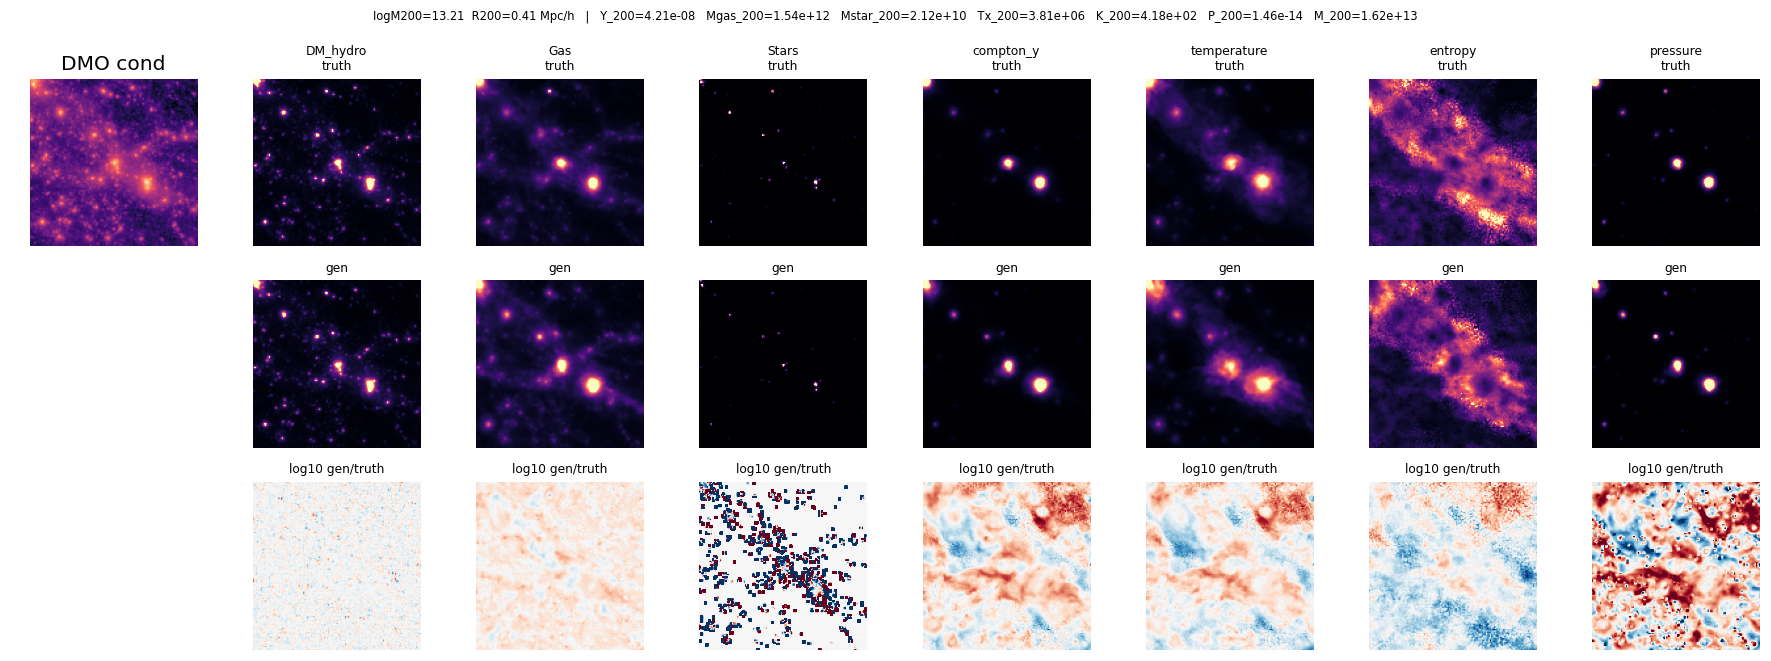

/tmp/ipykernel_50901/4050213584.py:13: RuntimeWarning: overflow encountered in divide
  ax[2, c+1].imshow(np.log10((g+1e-30)/(t+1e-30)), vmin=-1, vmax=1, cmap='RdBu_r')


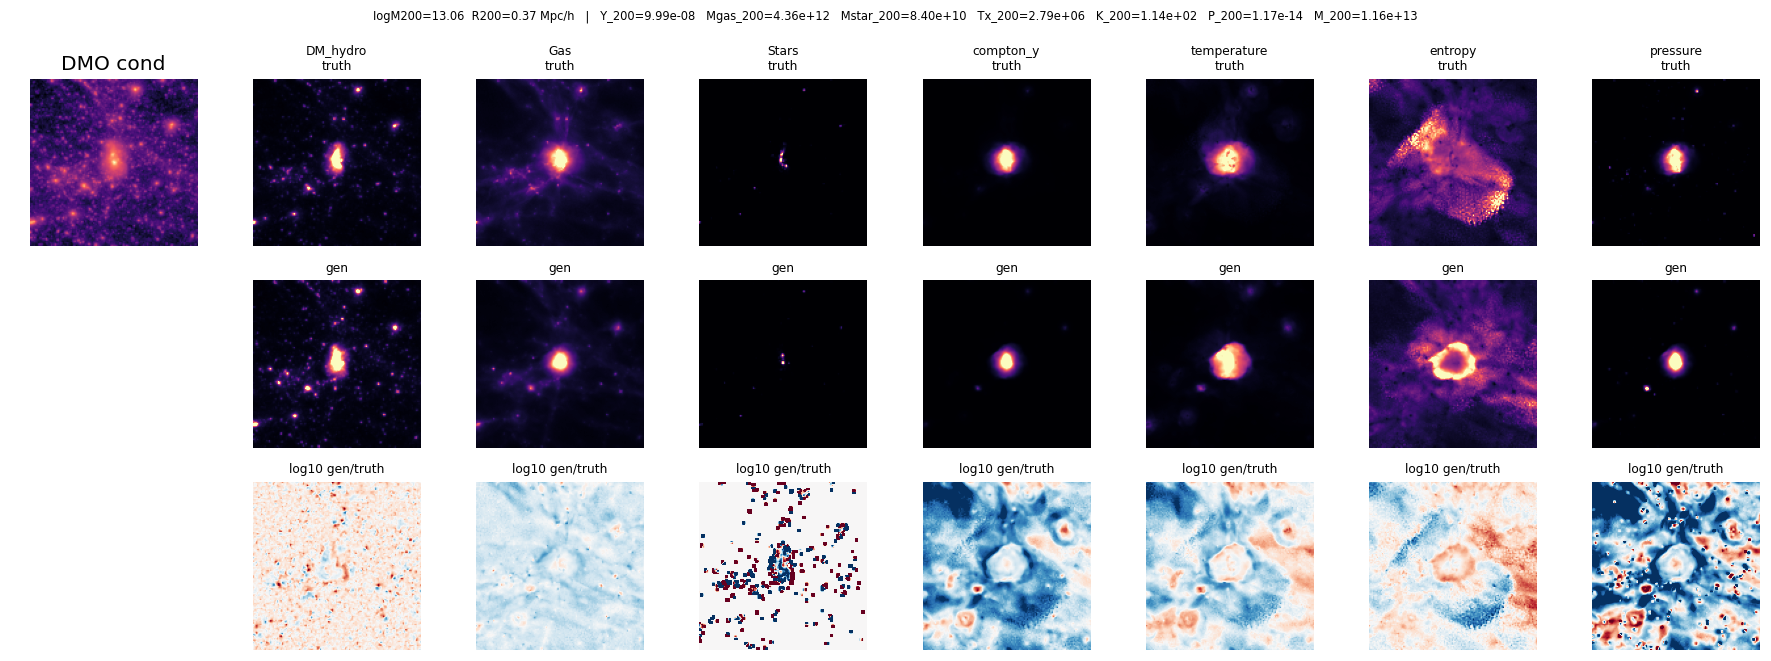

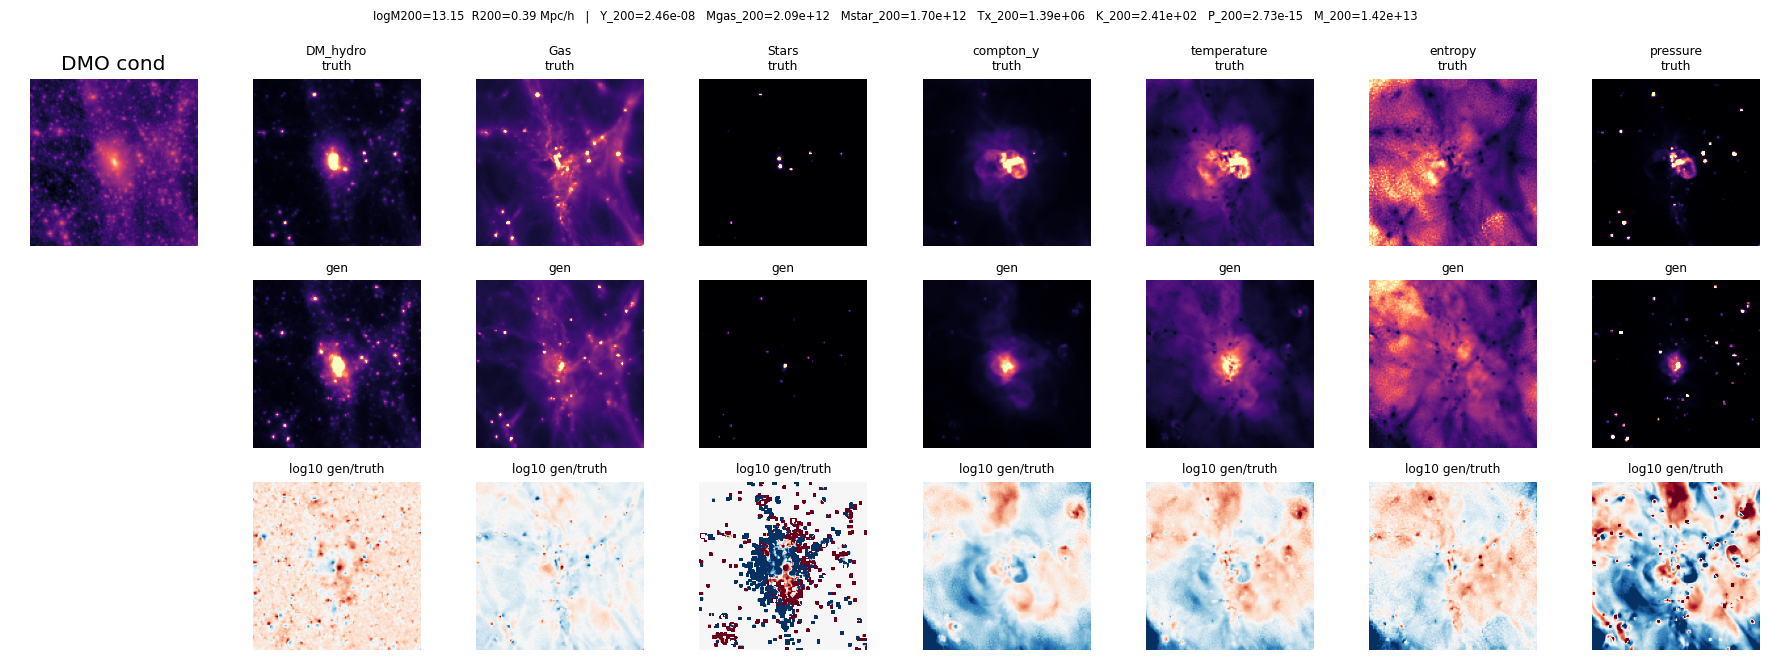

In [4]:
def show_halo(j, vmax_q=99.5):
    d = np.load(test_files[idx[j]])
    ncol = len(CHANNELS) + 1
    fig, ax = plt.subplots(3, ncol, figsize=(2.05*ncol, 6.1))
    ax[0,0].imshow(np.log10(d['condition']+1), cmap='magma'); ax[0,0].set_title('DMO cond')
    ax[1,0].axis('off'); ax[2,0].axis('off'); ax[0,0].axis('off')
    for c, name in enumerate(CHANNELS):
        t, g = truth_phys[j, c], gen_phys[j, c]
        pos = t[t > 0]; vmax = np.percentile(pos, vmax_q) if pos.size else 1.0
        kw = dict(vmin=0, vmax=vmax, cmap='magma')
        ax[0, c+1].imshow(t, **kw); ax[0, c+1].set_title(f'{name}\ntruth', fontsize=8)
        ax[1, c+1].imshow(g, **kw); ax[1, c+1].set_title('gen', fontsize=8)
        ax[2, c+1].imshow(np.log10((g+1e-30)/(t+1e-30)), vmin=-1, vmax=1, cmap='RdBu_r')
        ax[2, c+1].set_title('log10 gen/truth', fontsize=8)
        for r in range(3): ax[r, c+1].axis('off')
    obs = compute_observables(d)
    fig.suptitle('logM200=%.2f  R200=%.2f Mpc/h   |   ' % (
        np.log10(float(d['halo_mass'])), r200_from_sample(d))
        + '   '.join(f'{k}={v:.2e}' for k, v in zip(OBSERVABLE_KEYS, obs)), fontsize=7.5)
    plt.tight_layout(); plt.show()

for j in range(3):
    show_halo(j)

### Per-channel reconstruction error (dex) and stacked radial profiles

In [5]:
print(f'{"channel":12s} {"dex bias":>10s} {"dex scatter":>12s} {"n_pix":>10s}')
for c, name in enumerate(CHANNELS):
    g = gen_phys[:, c].ravel(); t = truth_phys[:, c].ravel()
    mask = (g > 0) & (t > 0)
    dd = np.log10(g[mask]) - np.log10(t[mask])
    print(f'{name:12s} {np.median(dd):10.3f} {np.std(dd):12.3f} {int(mask.sum()):10d}')

channel        dex bias  dex scatter      n_pix
DM_hydro          0.003        0.146    1048576
Gas              -0.018        0.147    1048576
Stars             0.046        1.075     145120
compton_y        -0.002        0.371    1048576
temperature       0.013        0.307    1048576
entropy           0.014        0.324    1048576
pressure          0.010        0.548    1048576


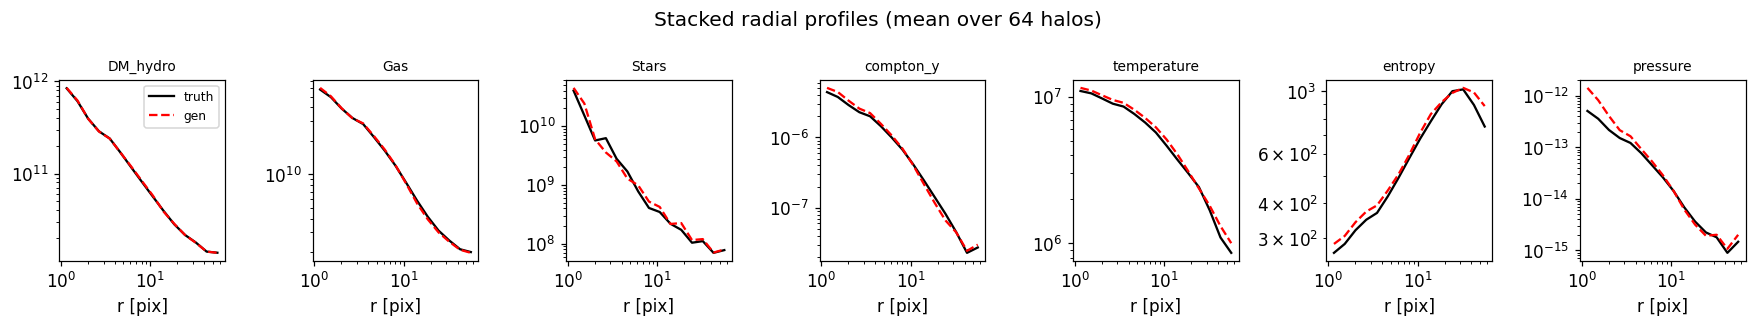

In [6]:
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(2.3*len(CHANNELS), 3.0))
for c, name in enumerate(CHANNELS):
    rc, _ = radial_profile(truth_phys[0, c])
    pt = np.stack([radial_profile(truth_phys[j, c])[1] for j in range(len(idx))]).mean(0)
    pg = np.stack([radial_profile(gen_phys[j, c])[1] for j in range(len(idx))]).mean(0)
    axes[c].plot(rc, pt, 'k-', label='truth'); axes[c].plot(rc, pg, 'r--', label='gen')
    axes[c].set_xscale('log'); axes[c].set_yscale('log')
    axes[c].set_title(name, fontsize=9); axes[c].set_xlabel('r [pix]')
    if c == 0: axes[c].legend(fontsize=8)
fig.suptitle('Stacked radial profiles (mean over %d halos)' % len(idx))
plt.tight_layout(); plt.show()

## 3. Conditioning response — does the model *use* the observables?

Take one halo, hold its DMO cutout and all-but-one observable fixed, and sweep a single observable over
±dex (in physical units → a normalized shift of `Δdex / obs_std`). We reuse the **same initial noise**
each time, so any change in the painted field is due to the conditioning alone. A model that ignores the
observables would produce identical panels.

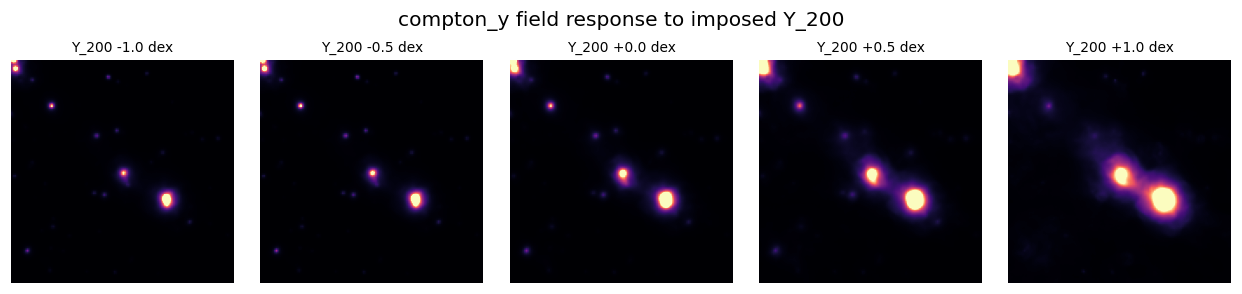

In [7]:
j = 0
base = batch['params'][j:j+1].clone()          # raw normalized N_OBS observable vector for halo j
cond1 = batch['condition'][j:j+1].to(device)
ls1   = batch['large_scale'][j:j+1].to(device)

FEATURE = 'Y_200'                              # try 'Mgas_200', 'P_200', 'M_200', 'Tx_200', ...
WATCH   = 'compton_y'                          # output channel to watch respond
fi = list(OBSERVABLE_KEYS).index(FEATURE)
ch = CHANNELS.index(WATCH)
deltas = [-1.0, -0.5, 0.0, 0.5, 1.0]           # dex offsets imposed on the observable

def gen_with_offset(dlt):
    v = base.clone()
    v[0, fi] = v[0, fi] + dlt / (ns.obs_std[fi] + 1e-8)
    torch.manual_seed(0)                       # identical noise -> isolate conditioning effect
    with torch.no_grad():
        g = fm.sample(cond1, ls1, make_cond(v).to(device), n_steps=N_STEPS)
    return _denormalize_to_physical(g.float().cpu().numpy(), ns)[0]

panels = [gen_with_offset(d) for d in deltas]
vmax = np.percentile(panels[2][ch][panels[2][ch] > 0], 99.5)
fig, ax = plt.subplots(1, len(deltas), figsize=(2.3*len(deltas), 2.7))
for k, dlt in enumerate(deltas):
    ax[k].imshow(panels[k][ch], vmin=0, vmax=vmax, cmap='magma')
    ax[k].set_title(f'{FEATURE} {dlt:+.1f} dex', fontsize=9); ax[k].axis('off')
fig.suptitle(f'{WATCH} field response to imposed {FEATURE}')
plt.tight_layout(); plt.show()

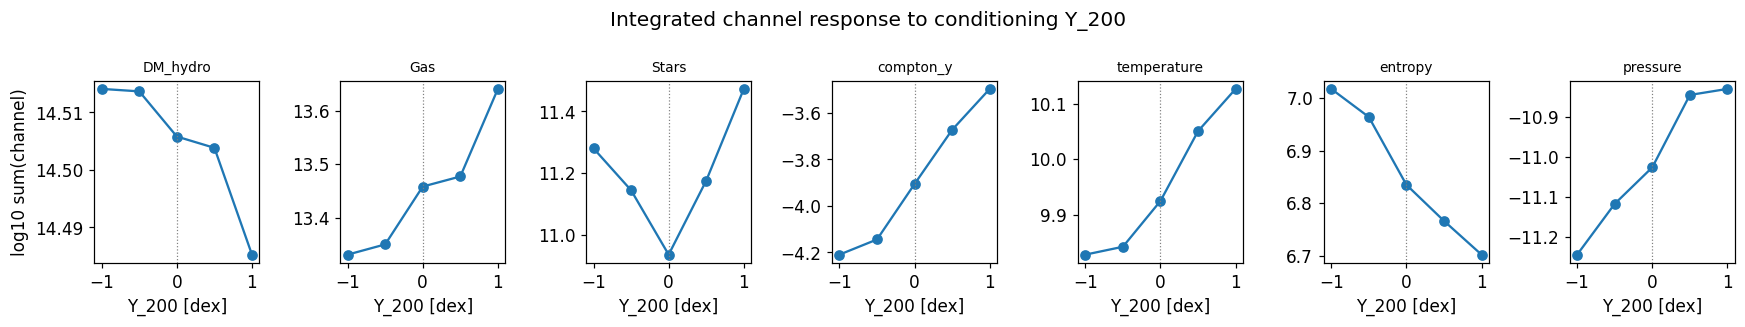

In [8]:
# Quantitative: integrated response of every output channel vs the imposed observable.
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(2.3*len(CHANNELS), 3.0))
sums = np.array([[panels[k][c].sum() for c in range(len(CHANNELS))] for k in range(len(deltas))])
for c, name in enumerate(CHANNELS):
    axes[c].plot(deltas, np.log10(sums[:, c] + 1e-30), 'o-')
    axes[c].set_title(name, fontsize=9); axes[c].set_xlabel(f'{FEATURE} [dex]')
    axes[c].axvline(0, color='gray', ls=':', lw=0.8)
axes[0].set_ylabel('log10 sum(channel)')
fig.suptitle(f'Integrated channel response to conditioning {FEATURE}')
plt.tight_layout(); plt.show()

## 4. Subset conditioning — predict the *withheld* observables (needs a masked model)

The payoff of `--mask_observables`: condition on only what a survey delivers (here SZ `Y` + X-ray `Tx` + lensing `M`) and let the model **predict** the rest. Re-measuring the generated maps gives BIND's prediction for the withheld `Mgas, Mstar, K, P` — and hence **f_b = (Mgas + Mstar)/M200**, a genuine prediction since its numerator was never an input. The `given` panels (gray) should fall on the 1:1 line (consistency); the `PREDICT` panels (red) are the science. Falls back to a message on an unmasked checkpoint.

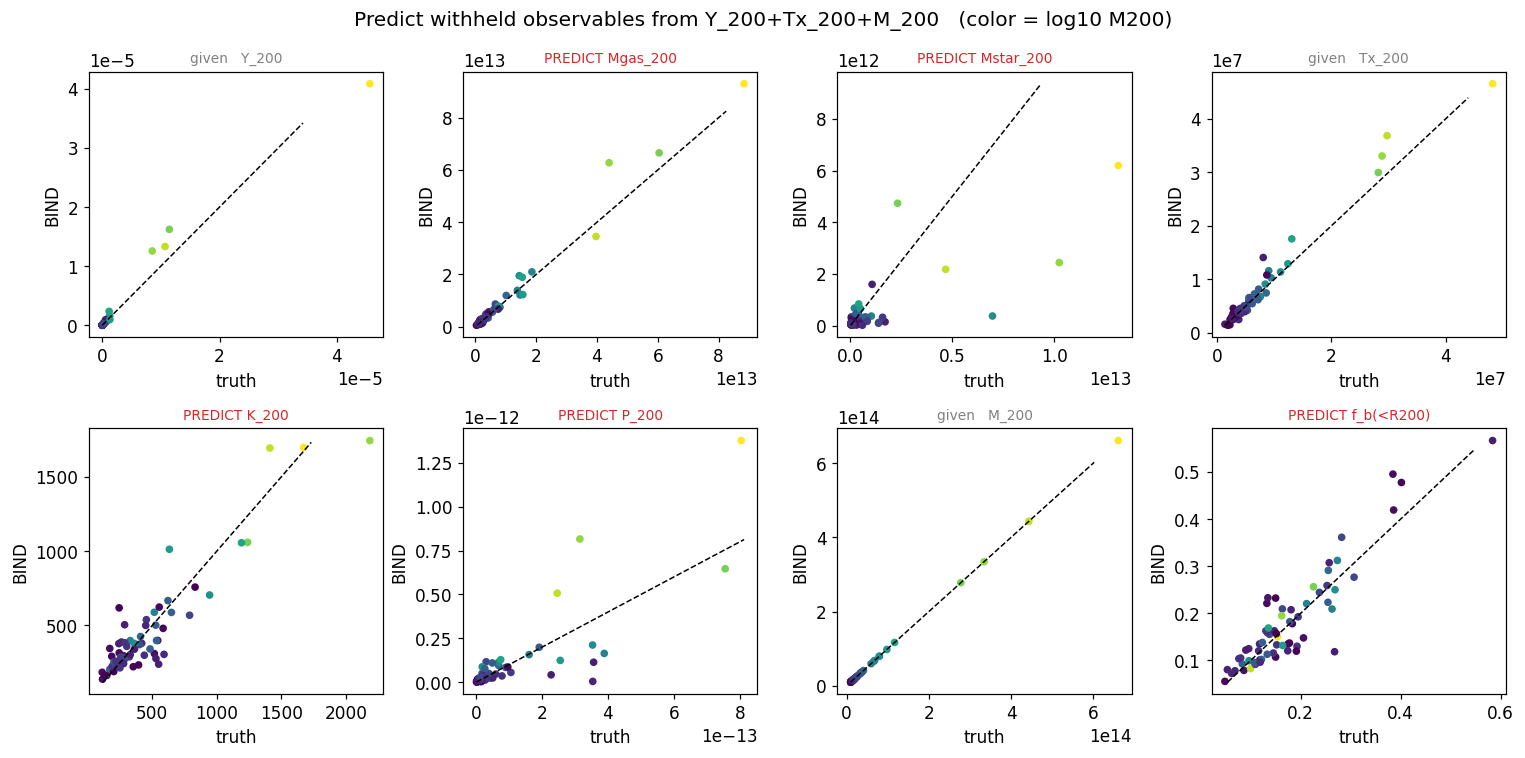

median f_b bias (pred - truth): +0.007  | scatter 0.043  over 64 halos


In [9]:
# Predict the WITHHELD observables (incl Mgas, Mstar -> f_b) from a survey-like subset.
SUBSET = ['Y_200', 'Tx_200', 'M_200']          # e.g. SZ + X-ray temperature + lensing mass
if not MASKED:
    print('Subset conditioning needs a --mask_observables checkpoint (e.g. fm_observables_masked).')
    print('Train it:  MASK=1 OBS=1 sbatch run_train.sh   then point OBS_RUN_DIR at that run.')
else:
    keep = np.array([k in SUBSET for k in OBSERVABLE_KEYS], dtype=np.float32)
    with torch.no_grad():
        g = fm.sample(cond, ls, make_cond(batch['params'], keep).to(device), n_steps=N_STEPS)
    gen_sub = _denormalize_to_physical(g.float().cpu().numpy(), ns)   # (N, 3+N_THERMO, H, W)

    def obs_from_maps(maps, M, r200):
        """Re-measure the N_OBS observables from generated maps (same definition as training)."""
        d = {'target': maps[:3], 'halo_mass': M, 'r200': r200}
        for jj, k in enumerate(THERMO_KEYS):
            d[k] = maps[3 + jj]
        return compute_observables(d)

    pred, truth = [], []
    for n, i in enumerate(idx):
        d = np.load(test_files[i]); M = float(d['halo_mass']); r2 = r200_from_sample(d)
        pred.append(obs_from_maps(gen_sub[n], M, r2))
        truth.append(compute_observables(d))
    pred, truth = np.array(pred), np.array(truth)
    gi, si, mi = (OBSERVABLE_KEYS.index(k) for k in ('Mgas_200', 'Mstar_200', 'M_200'))
    mvec = np.log10(truth[:, mi])
    fb_pred  = (pred[:, gi]  + pred[:, si])  / pred[:, mi]    # numerator WITHHELD -> real prediction
    fb_truth = (truth[:, gi] + truth[:, si]) / truth[:, mi]

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for a, c in zip(axes.ravel(), range(N_OBS)):
        held = OBSERVABLE_KEYS[c] not in SUBSET
        a.scatter(truth[:, c], pred[:, c], c=mvec, cmap='viridis', s=16)
        lo, hi = np.percentile(np.r_[truth[:, c], pred[:, c]], [1, 99]); a.plot([lo, hi], [lo, hi], 'k--', lw=1)
        a.set_title(('PREDICT ' if held else 'given   ') + OBSERVABLE_KEYS[c],
                    color=('C3' if held else 'gray'), fontsize=9)
        a.set_xlabel('truth'); a.set_ylabel('BIND')
    a = axes.ravel()[7]
    a.scatter(fb_truth, fb_pred, c=mvec, cmap='viridis', s=16)
    lo, hi = np.percentile(np.r_[fb_truth, fb_pred], [1, 99]); a.plot([lo, hi], [lo, hi], 'k--', lw=1)
    a.set_title('PREDICT f_b(<R200)', color='C3', fontsize=9); a.set_xlabel('truth'); a.set_ylabel('BIND')
    fig.suptitle('Predict withheld observables from %s   (color = log10 M200)' % '+'.join(SUBSET))
    plt.tight_layout(); plt.show()
    print(f'median f_b bias (pred - truth): {np.median(fb_pred - fb_truth):+.3f}  '
          f'| scatter {np.std(fb_pred - fb_truth):.3f}  over {len(idx)} halos')

## Notes

- **Reconstruction** conditions on truth-measured observables — the natural validation while the run
  trains. A monotone response in section 3 confirms the model actually uses the conditioning.
- Suite-level evaluation is wired: `bind-camels-suite` auto-detects observable models
  (`norm_stats.condition_observables`) and measures the per-halo observables from the truth maps
  (`build_observable_vectors`), so it works end-to-end when truth is available.
- Deploying on **real** observed scalars (not truth-derived) is the same path — just pass your measured
  `(Y_200, Mgas_200, Mstar_200, Tx_200, K_200, P_200, M_200)` through `thermo_forward(obs, ns.obs_mean,
  ns.obs_std, ns.obs_floor)` and into `fm.sample` as the conditioning vector.
- Swap `OBS_CKPT=epoch0NN-...ckpt` to compare epochs as the run progresses.